# NIFTY 50 Implied Volatility Surface Reconstruction
**IIT Roorkee Finance Club Open Project 2026**

**Objective:** Impute missing Implied Volatility (IV) values across the NIFTY 50 options chain without lookahead bias.  
**Evaluation Metric:** Mean Squared Error (MSE) - lower is better.
**Best Leaderboard Result:** MSE `0.00004308`


## Project Summary

The core insight was that mathematics beats machine learning for this problem. The IV surface is a smooth, analytically-defined manifold — trying to approximate it with tree-based step functions introduces unnecessary variance. The best approach uses a Regime-Switching Pure Quant Interpolator: a Natural Cubic Spline for normal days, and Linear Interpolation on Expiry Day.

### Notebook Structure
1. Setup & Data Loading - imports and raw data overview
2. EDA Phase 1: Data Restructuring - wide → long format, feature extraction
3. EDA Phase 2: Missing Data Analysis - where, when, and why values are missing
4. EDA Phase 3: Volatility Surface Visualization - smile, skew, term structure, 3D surface
5. Approach 1: PCHIP Baseline + LightGBM Residual (MSE: 0.00275)
6. Approach 2: Pure PCHIP + Temporal Fill (MSE: 0.01122)
7. Approach 3: PCHIP + Flat Wing Extrapolation (MSE: 0.00105)
8. Approach 4: Regime-Switching: PCHIP / Linear (MSE: 0.00043)
9. Approach 5: CV Framework + Regime Switching (MSE: 0.00104)
10. Approach 6: Natural Cubic Spline + CV (MSE: 0.0000431)
11. Final Submission Cell: clean, reproducible inference


IMPORTANT: The naming of final .csv files are based on submissions made during the competition.

## 1. Setup & Data Loading

Import all required libraries.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import pchip_interpolate, PchipInterpolator, CubicSpline, interp1d
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

# For plotting
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [36]:
df = pd.read_csv('dataset.csv')
print(f"Shape: {df.shape}")
print(f"Columns: datetime, underlying_price + {df.shape[1] - 2} option tickers")
df.head(3)

Shape: (975, 30)
Columns: datetime, underlying_price + 28 option tickers


,datetime,underlying_price,NIFTY27JAN2625200CE,NIFTY27JAN2625300CE,NIFTY27JAN2625400CE,NIFTY27JAN2625500CE,NIFTY27JAN2625600CE,NIFTY27JAN2625700CE,NIFTY27JAN2625800CE,NIFTY27JAN2625900CE,...,NIFTY27JAN2624200PE,NIFTY27JAN2624300PE,NIFTY27JAN2624400PE,NIFTY27JAN2624500PE,NIFTY27JAN2624600PE,NIFTY27JAN2624700PE,NIFTY27JAN2624800PE,NIFTY27JAN2624900PE,NIFTY27JAN2625000PE,NIFTY27JAN2625100PE
0,07-01-2026 09:15,26111.65,0.12662,0.1233,0.11741,NaN,0.11005,0.10576,NaN,0.09724,...,0.15760,0.1524,0.14697,0.14105,0.13613,0.13085,0.12640,0.12142,0.11631,0.11150
1,07-01-2026 09:20,26141.40,0.08632,NaN,NaN,0.11779,0.11197,0.11028,NaN,NaN,...,NaN,0.1542,0.14753,0.14274,0.13849,0.13282,NaN,0.12363,NaN,0.11353
2,07-01-2026 09:25,26139.35,0.09147,NaN,0.09514,0.09933,0.09599,0.09204,0.09216,0.08954,...,0.15927,NaN,0.14919,0.14245,0.13806,0.13242,0.12877,0.12349,0.11817,NaN



## 2. EDA Phase 1 - Data Restructuring

We melt dataset into long format where each row is a single (timestamp, contract, IV) observation. From there we extract the financially meaningful coordinates: strike, option type, Time-To-Maturity (TTM), and Moneyness.

In [37]:
# Wide → Long format
index_cols  = ['datetime', 'underlying_price']
ticker_cols = [c for c in df.columns if c not in index_cols]

df_long = pd.melt(df, id_vars=index_cols, value_vars=ticker_cols,
                  var_name='ticker', value_name='iv')

# Parse ticker: like NIFTY27JAN2625200CE → expiry=27JAN26, strike=25200, type=CE
extracted = df_long['ticker'].str.extract(r'NIFTY(\d{2}[A-Z]{3}\d{2})(\d+)(CE|PE)')
df_long['expiry_str'] = extracted[0]
df_long['strike'] = extracted[1].astype(float)
df_long['option_type'] = extracted[2]

# Financial coordinates
df_long['datetime'] = pd.to_datetime(df_long['datetime'], format='%d-%m-%Y %H:%M')
expiry_dt = pd.to_datetime('2026-01-27 15:30:00')   # Exchange closes at 15:30 IST

df_long['ttm_minutes'] = (expiry_dt - df_long['datetime']).dt.total_seconds() / 60.0
df_long['ttm_days'] = df_long['ttm_minutes'] / 375          # ~375 trading minutes/day
df_long['moneyness'] = df_long['strike'] / df_long['underlying_price']
df_long['log_moneyness'] = np.log(df_long['moneyness'])

# Sort chronologically (to avoid lookahead bias)
df_long = df_long.sort_values(['datetime', 'strike']).reset_index(drop=True)

print(f"Long format shape: {df_long.shape}")
print(f"Unique strikes: {df_long['strike'].nunique()}, Timestamps: {df_long['datetime'].nunique()}")
df_long.head(5)

Long format shape: (27300, 11)
Unique strikes: 28, Timestamps: 975


,datetime,underlying_price,ticker,iv,expiry_str,strike,option_type,ttm_minutes,ttm_days,moneyness,log_moneyness
0,2026-01-07 09:15:00,26111.65,NIFTY27JAN2623800PE,0.17840,27JAN26,23800.0,PE,29175.0,77.8,0.911471,-0.092696
1,2026-01-07 09:15:00,26111.65,NIFTY27JAN2623900PE,0.17237,27JAN26,23900.0,PE,29175.0,77.8,0.915300,-0.088503
2,2026-01-07 09:15:00,26111.65,NIFTY27JAN2624000PE,0.16928,27JAN26,24000.0,PE,29175.0,77.8,0.919130,-0.084328
3,2026-01-07 09:15:00,26111.65,NIFTY27JAN2624100PE,NaN,27JAN26,24100.0,PE,29175.0,77.8,0.922960,-0.080170
4,2026-01-07 09:15:00,26111.65,NIFTY27JAN2624200PE,0.15760,27JAN26,24200.0,PE,29175.0,77.8,0.926789,-0.076029


## 3. EDA Phase 2 - Missing Data Analysis

Before modeling, we need to understand *where* and *when* the IV is missing. A strike that is systematically absent at market open requires different treatment than one that is occasionally illiquid.

In [38]:
# Overall missing rate
total_missing = df_long['iv'].isna().sum()
total_obs = len(df_long)
print(f"Total observations : {total_obs:,}")
print(f"Missing values     : {total_missing:,}  ({total_missing/total_obs:.1%})")

# Missing by option type
print("\nMissing by option type:")
print(df_long.groupby('option_type')['iv'].apply(lambda x: x.isna().mean()).round(4))

Total observations : 27,300
Missing values     : 5,460  (20.0%)

Missing by option type:
option_type
CE    0.1971
PE    0.2029
Name: iv, dtype: float64


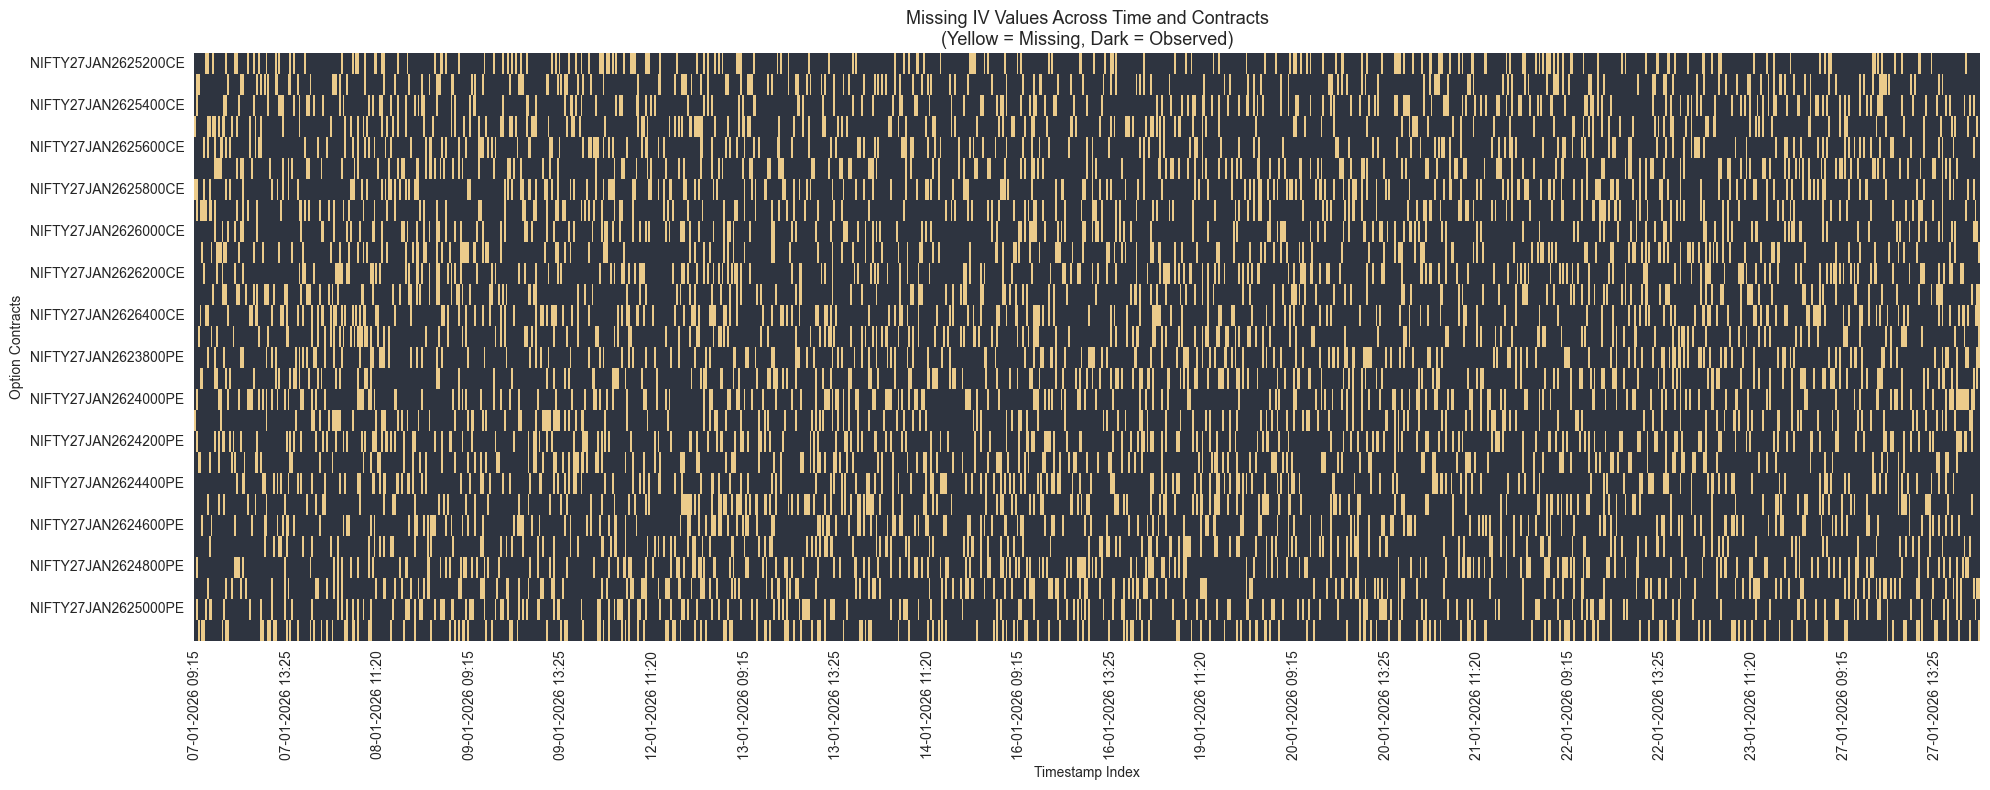

In [39]:
# Heatmap: missingness across all contracts over time
# Yellow = missing, dark = observed.
mask_wide = (df.set_index('datetime')
               .drop(columns=['underlying_price'])
               .isna()
               .T)

fig, ax = plt.subplots(figsize=(20, 8))
sns.heatmap(mask_wide, cmap=['#2E3440', '#EBCB8B'], cbar=False,
            yticklabels=2, xticklabels=50, ax=ax)
ax.set_title('Missing IV Values Across Time and Contracts\n(Yellow = Missing, Dark = Observed)', fontsize=13)
ax.set_xlabel('Timestamp Index')
ax.set_ylabel('Option Contracts')
plt.tight_layout()
plt.show()

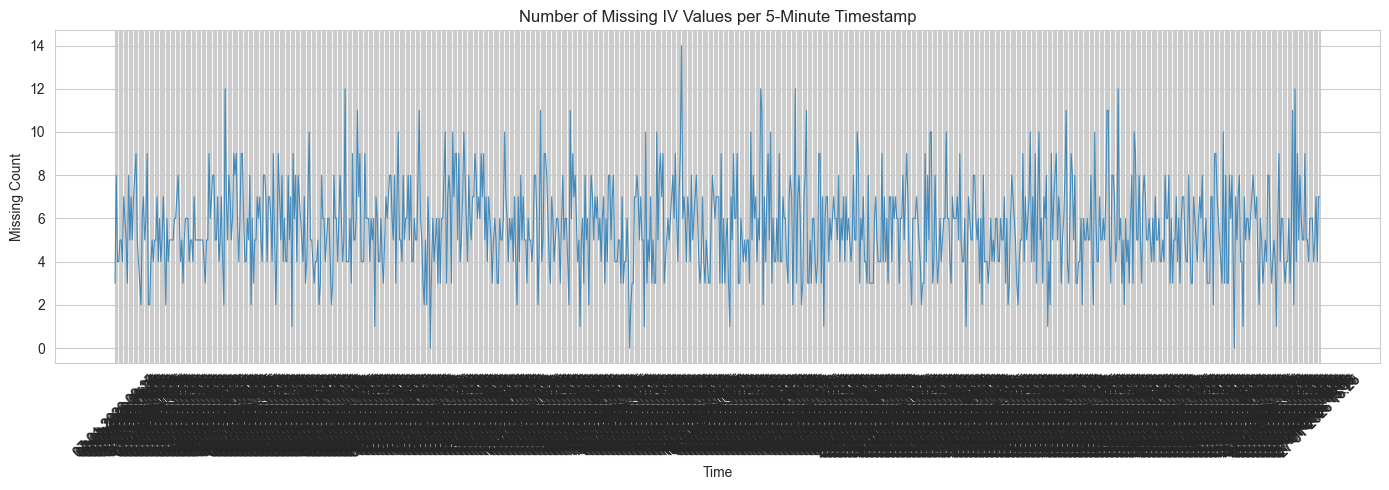


Timestamps with most missing values (top 10):
datetime
16-01-2026 09:55    14
08-01-2026 10:25    12
19-01-2026 11:20    12
22-01-2026 14:20    12
09-01-2026 12:15    12
16-01-2026 15:15    12
27-01-2026 13:45    12
12-01-2026 11:00    11
22-01-2026 10:50    11
13-01-2026 14:55    11
dtype: int64


In [40]:
# Missing values per timestamp — reveals noisy market open/close
missing_per_time = (df.drop(columns=['datetime', 'underlying_price'])
                      .isna().sum(axis=1))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['datetime'], missing_per_time, linewidth=0.8, alpha=0.8)
ax.set_title('Number of Missing IV Values per 5-Minute Timestamp')
ax.set_ylabel('Missing Count')
ax.set_xlabel('Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nTimestamps with most missing values (top 10):")
top_missing = (df.set_index('datetime')
                 .drop(columns=['underlying_price'])
                 .isna().sum(axis=1)
                 .sort_values(ascending=False)
                 .head(10))
print(top_missing)

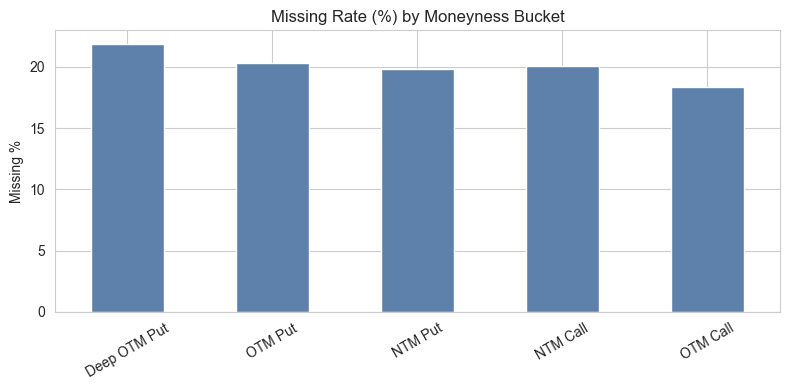


Key finding: Deep OTM wing strikes have higher missing rates: consistent with liquidity-driven absences.


In [41]:
# Missing rate by moneyness bucket
df_long['moneyness_bucket'] = pd.cut(df_long['moneyness'],
                                      bins=[0.88, 0.92, 0.96, 1.0, 1.04, 1.08, 1.12],
                                      labels=['Deep OTM Put', 'OTM Put', 'NTM Put',
                                              'NTM Call', 'OTM Call', 'Deep OTM Call'])

miss_by_moneyness = (df_long.groupby('moneyness_bucket', observed=True)['iv']
                             .apply(lambda x: x.isna().mean())
                             .mul(100).round(2))

fig, ax = plt.subplots(figsize=(8, 4))
miss_by_moneyness.plot(kind='bar', ax=ax, color='#5E81AC', edgecolor='white')
ax.set_title('Missing Rate (%) by Moneyness Bucket')
ax.set_ylabel('Missing %')
ax.set_xlabel('')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("\nKey finding: Deep OTM wing strikes have higher missing rates: consistent with liquidity-driven absences.")

## 4. EDA Phase 3 - Volatility Surface Visualization

Visualizing the IV surface confirms the two most important structural features we need our interpolator to respect:
- Volatility Smile / Skew - IV is U-shaped across strikes; deep OTM puts carry elevated IV
- Time Continuity - the surface evolves gradually, except on Expiry Day when Gamma explodes

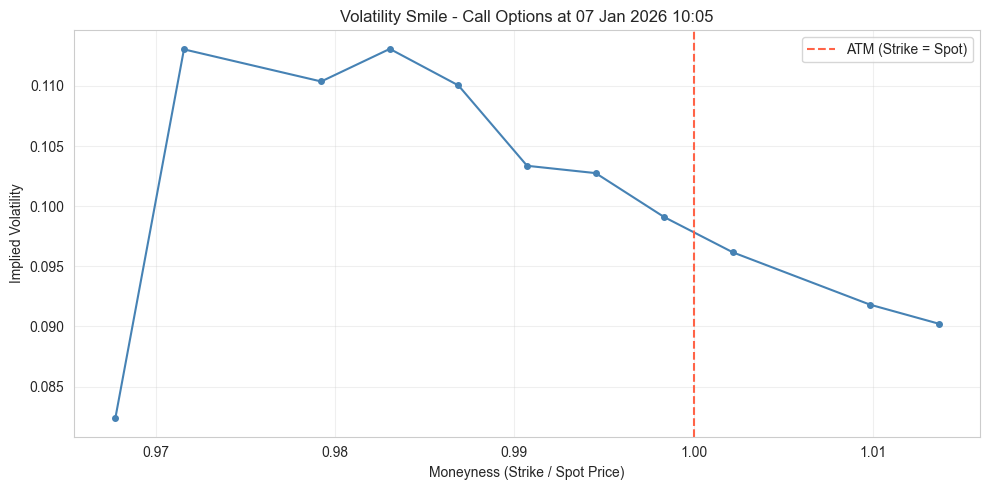

In [42]:
# Volatility Smile at a representative timestamp
sample_time = df_long['datetime'].unique()[10]  # Pick a mid-day snapshot
smile_data  = df_long[(df_long['datetime'] == sample_time) & (df_long['option_type'] == 'CE')].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(smile_data['moneyness'], smile_data['iv'], marker='o', linestyle='-', color='steelblue', markersize=4)
ax.axvline(x=1.0, color='tomato', linestyle='--', linewidth=1.5, label='ATM (Strike = Spot)')
ax.set_title(f"Volatility Smile - Call Options at {pd.to_datetime(sample_time).strftime('%d %b %Y %H:%M')}")
ax.set_xlabel('Moneyness (Strike / Spot Price)')
ax.set_ylabel('Implied Volatility')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

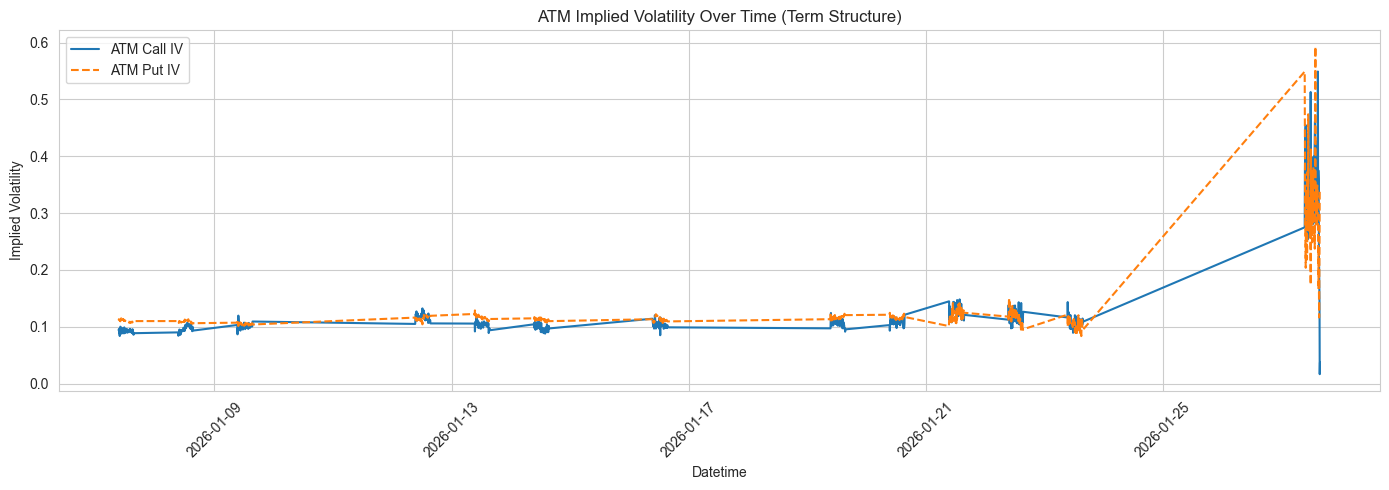

In [43]:
# ATM IV Term Structure
df_long['abs_diff_from_atm'] = (df_long['moneyness'] - 1.0).abs()
idx_atm  = df_long.groupby(['datetime', 'option_type'])['abs_diff_from_atm'].idxmin()
atm_data = df_long.loc[idx_atm].dropna(subset=['iv'])

fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=atm_data[atm_data['option_type'] == 'CE'], x='datetime', y='iv',
             label='ATM Call IV', ax=ax)
sns.lineplot(data=atm_data[atm_data['option_type'] == 'PE'], x='datetime', y='iv',
             label='ATM Put IV', ax=ax, linestyle='--')
ax.set_title('ATM Implied Volatility Over Time (Term Structure)')
ax.set_xlabel('Datetime')
ax.set_ylabel('Implied Volatility')
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

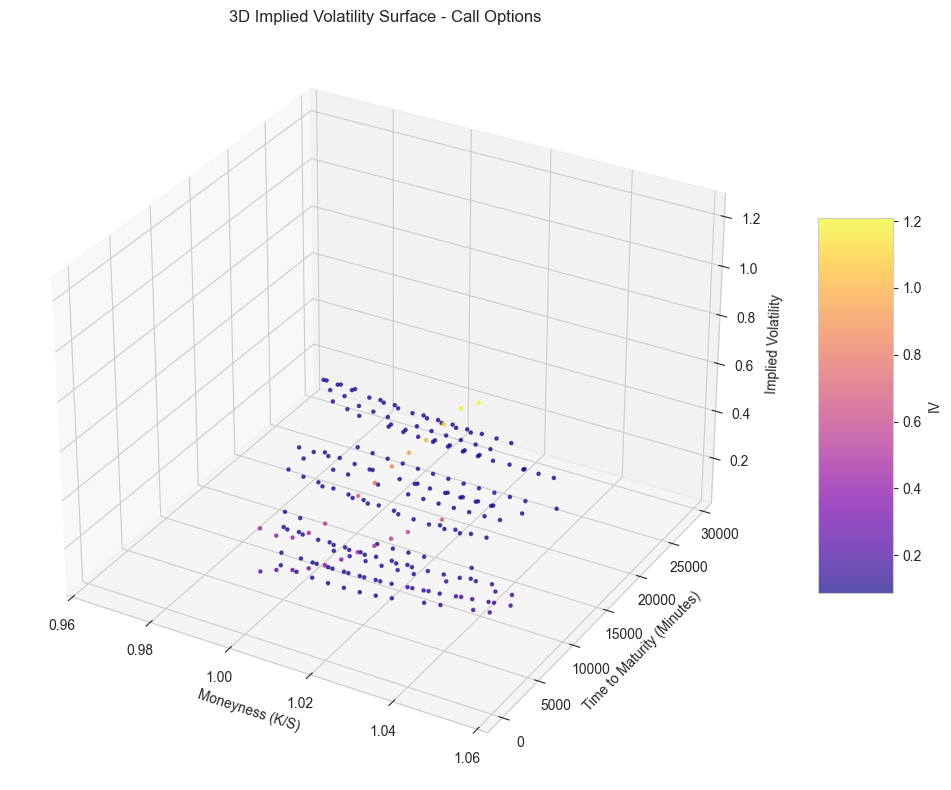

In [44]:
# 3D IV Surface - Moneyness × TTM × IV
# Sample every 50th timestamp to keep the plot readable
sample_times = df_long['datetime'].unique()[::50]
surface_ce   = df_long[(df_long['datetime'].isin(sample_times)) &
                        (df_long['option_type'] == 'CE')].dropna(subset=['iv'])

fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(111, projection='3d')
sc  = ax.scatter(surface_ce['moneyness'], surface_ce['ttm_minutes'], surface_ce['iv'],
                  c=surface_ce['iv'], cmap='plasma', marker='o', s=5, alpha=0.7)
ax.set_title('3D Implied Volatility Surface - Call Options')
ax.set_xlabel('Moneyness (K/S)')
ax.set_ylabel('Time to Maturity (Minutes)')
ax.set_zlabel('Implied Volatility')
fig.colorbar(sc, ax=ax, shrink=0.5, aspect=5, label='IV')
plt.tight_layout()
plt.show()

## 5. Approach 1 - PCHIP Baseline + LightGBM Residual Corrector
**Leaderboard MSE: 0.0027478**

Fit a PCHIP spline as a baseline, then train a gradient boosting model to predict the errors. This should have worked but apparantely didn't.
The Identity Function Trap: When we train the residual model on observed points, the PCHIP interpolator passes through them exactly (residual = 0). So we're training LightGBM to learn `y = 0` everywhere. The model overfits this zero-residual signal and introduces massive step-function variance on the actual missing values.

In [45]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from scipy.interpolate import pchip_interpolate

# 1. Load and reshape
df = pd.read_csv('dataset.csv')
id_vars    = ['datetime', 'underlying_price']
value_vars = [col for col in df.columns if col not in id_vars]

df_long = df.melt(id_vars=id_vars, value_vars=value_vars, var_name='ticker', value_name='IV')
df_long['is_missing_original'] = df_long['IV'].isnull()

# 2. Feature engineering
df_long['strike']       = df_long['ticker'].str.extract(r'(\d{4,5})(?:CE|PE)').astype(float)
df_long['option_type']  = df_long['ticker'].str.extract(r'(CE|PE)')
df_long['is_call']      = (df_long['option_type'] == 'CE').astype(int)

df_long['datetime_obj'] = pd.to_datetime(df_long['datetime'], format='%d-%m-%Y %H:%M')
expiry_date_full        = pd.to_datetime('2026-01-27') + pd.Timedelta(hours=15, minutes=30)
df_long['minutes_to_expiry'] = (expiry_date_full - df_long['datetime_obj']).dt.total_seconds() / 60.0
df_long['moneyness']    = df_long['strike'] / df_long['underlying_price']
df_long['log_moneyness'] = np.log(df_long['moneyness'])

df_long = df_long.sort_values(['datetime_obj', 'strike', 'option_type']).reset_index(drop=True)

# 3. PCHIP baseline
def interpolate_group(group, iv_col):
    observed = group.dropna(subset=[iv_col])
    missing  = group[group[iv_col].isnull()]
    if len(observed) >= 2 and len(missing) > 0:
        observed = observed.sort_values('strike')
        group.loc[missing.index, iv_col] = pchip_interpolate(
            observed['strike'].values, observed[iv_col].values, missing['strike'].values)
    return group

df_long['IV_baseline'] = df_long['IV']
df_long = df_long.groupby(['datetime_obj', 'option_type'], group_keys=False).apply(
    lambda g: interpolate_group(g, 'IV_baseline'))
df_long['IV_baseline'] = df_long.groupby(['strike', 'option_type'])['IV_baseline'].ffill()
df_long['IV_baseline'] = df_long['IV_baseline'].fillna(
    df_long.groupby(['datetime_obj', 'option_type'])['IV_baseline'].transform('mean'))

# Randomly hide 20% of observed values
np.random.seed(42)
known_indices = df_long[~df_long['is_missing_original']].index
mask_indices  = np.random.choice(known_indices, size=int(len(known_indices) * 0.20), replace=False)

df_long['IV_for_training'] = df_long['IV']
df_long.loc[mask_indices, 'IV_for_training'] = np.nan

# Build PCHIP baseline on the masked dataset
df_long['IV_baseline_masked'] = df_long['IV_for_training']
df_long = df_long.groupby(['datetime_obj', 'option_type'], group_keys=False).apply(
    lambda g: interpolate_group(g, 'IV_baseline_masked'))
df_long['IV_baseline_masked'] = df_long.groupby(['strike', 'option_type'])['IV_baseline_masked'].ffill()
df_long['IV_baseline_masked'] = df_long['IV_baseline_masked'].fillna(
    df_long.groupby(['datetime_obj', 'option_type'])['IV_baseline_masked'].transform('mean'))

# 5. Train LightGBM on residuals
train_df = df_long[df_long.index.isin(mask_indices)].copy()

features = ['IV_baseline_masked', 'strike', 'moneyness', 'log_moneyness', 'minutes_to_expiry', 'is_call']
target   = 'IV'

model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.03, max_depth=5,
                            num_leaves=20, random_state=42, n_jobs=-1)
model.fit(train_df[features], train_df[target])

# 6. Predict missing values
test_df = df_long[df_long['is_missing_original']].copy()
test_df['IV_baseline_masked'] = test_df['IV_baseline']  # Use full baseline for test
test_df['predicted_IV']        = model.predict(test_df[features])

# ── 7. Build submission ───────────────────────────────────────────────────────
test_df['id'] = test_df['datetime'] + '||' + test_df['ticker']
submission_a1 = test_df[['id', 'predicted_IV']].rename(columns={'predicted_IV': 'value'})
submission_a1.to_csv('submission_1.csv', index=False)

print(f"Submission rows: {len(submission_a1)}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000379 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1051
[LightGBM] [Info] Number of data points in the train set: 4368, number of used features: 6
[LightGBM] [Info] Start training from score 0.181027
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

## 6. Approach 2 - Pure PCHIP + Temporal Forward Fill
**Leaderboard MSE: 0.01122**

Pure PCHIP cross-sectional interpolation, with temporal forward-fill as a fallback for strikes that go completely dark at a given timestamp. PCHIP was chosen over standard cubic splines because it is shape-preserving - it won't overshoot or create artificial wiggles between data points.

In [46]:
import pandas as pd
import numpy as np
from scipy.interpolate import PchipInterpolator

df = pd.read_csv('dataset.csv')
df['datetime'] = pd.to_datetime(df['datetime'], dayfirst=True)

cols         = [c for c in df.columns if c.startswith('NIFTY')]
calls        = sorted([c for c in cols if c.endswith('CE')], key=lambda x: int(x[12:-2]))
puts         = sorted([c for c in cols if c.endswith('PE')], key=lambda x: int(x[12:-2]))
call_strikes = np.array([int(c[12:-2]) for c in calls])
put_strikes  = np.array([int(c[12:-2]) for c in puts])

filled = df.copy()

# Cross-sectional PCHIP per timestamp
# For each 5-minute window, fit PCHIP on observed strikes and predict missing ones.
# Extrapolate=True handles strikes beyond the observed range.
for idx in range(len(df)):
    for group, strikes in [(calls, call_strikes), (puts, put_strikes)]:
        vals         = df.loc[idx, group].values.astype(float)
        missing_mask = np.isnan(vals)
        if not missing_mask.any():
            continue
        obs_mask = ~missing_mask
        if obs_mask.sum() >= 2:
            interp    = PchipInterpolator(strikes[obs_mask], vals[obs_mask], extrapolate=True)
            predicted = np.clip(interp(strikes[missing_mask]), 0.01, 2.0)
            filled.loc[idx, np.array(group)[missing_mask]] = predicted

# Temporal forward-fill fallback (no lookahead)
still_missing_before = filled[cols].isna().sum().sum()
filled[cols] = filled[cols].ffill().bfill()
print(f"Residual NaNs before temporal fill : {still_missing_before}")
print(f"Residual NaNs after  temporal fill : {filled[cols].isna().sum().sum()}")

original_missing_mask = df[cols].isna()
records = []
for col in cols:
    for row_idx in df.index[original_missing_mask[col]]:
        dt_str = df.loc[row_idx, 'datetime'].strftime('%d-%m-%Y %H:%M')
        records.append({'id': f"{dt_str}||{col}", 'value': filled.loc[row_idx, col]})

submission_a2 = pd.DataFrame(records, columns=['id', 'value'])
submission_a2.to_csv('submission_2.csv', index=False)

print(f"\nSubmission rows: {len(submission_a2)}")
print(f"Value range: [{submission_a2['value'].min():.4f}, {submission_a2['value'].max():.4f}]")

Residual NaNs before temporal fill : 0
Residual NaNs after  temporal fill : 0

Submission rows: 5460
Value range: [0.0113, 2.0000]


## 7. Approach 3 - PCHIP Belly + Flat Wing Extrapolation
**Leaderboard MSE: 0.00105**

A key financial insight: extrapolating a smooth curve into the deep wings is dangerous. PCHIP can oscillate as it projects beyond observed strikes, creating negative or explosive IVs. The financially conservative assumption for deep OTM options is flat extrapolation - carry the edge IV sideways.

In [47]:
import pandas as pd
import numpy as np
from scipy.interpolate import pchip_interpolate
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('dataset.csv')
id_vars    = ['datetime', 'underlying_price']
value_vars = [col for col in df.columns if col not in id_vars]

df_long = df.melt(id_vars=id_vars, value_vars=value_vars, var_name='ticker', value_name='IV')
df_long['is_missing']   = df_long['IV'].isnull()
df_long['strike']       = df_long['ticker'].str.extract(r'(\d{4,5})(?:CE|PE)').astype(float)
df_long['option_type']  = df_long['ticker'].str.extract(r'(CE|PE)')
df_long['datetime_obj'] = pd.to_datetime(df_long['datetime'], format='%d-%m-%Y %H:%M')
df_long = df_long.sort_values(['datetime_obj', 'strike', 'option_type']).reset_index(drop=True)

def apply_quant_interpolation(group):
    # PCHIP in the belly, flat extrapolation in the wings.
    observed = group.dropna(subset=['IV'])
    missing  = group[group['IV'].isnull()]

    if len(observed) >= 2 and len(missing) > 0:
        observed       = observed.sort_values('strike')
        missing_strikes = missing['strike'].values
        min_s, max_s   = observed['strike'].min(), observed['strike'].max()

        preds = []
        for s in missing_strikes:
            if s < min_s:
                preds.append(observed.iloc[0]['IV'])    # flat left wing
            elif s > max_s:
                preds.append(observed.iloc[-1]['IV'])   # flat right wing
            else:
                preds.append(pchip_interpolate(
                    observed['strike'].values, observed['IV'].values, s))  # PCHIP belly

        group.loc[missing.index, 'predicted_IV'] = preds
    return group

df_long['predicted_IV'] = df_long['IV']
df_long = df_long.groupby(['datetime_obj', 'option_type'], group_keys=False).apply(apply_quant_interpolation)

# Temporal safety net - strictly forward in time
df_long = df_long.sort_values(['ticker', 'datetime_obj']).reset_index(drop=True)
df_long['predicted_IV'] = df_long.groupby('ticker')['predicted_IV'].ffill()
df_long['predicted_IV'] = df_long.groupby('ticker')['predicted_IV'].bfill()

submission_a3 = df_long[df_long['is_missing']].copy()
submission_a3['id'] = submission_a3['datetime'] + '||' + submission_a3['ticker']
submission_a3 = submission_a3[['id', 'predicted_IV']].rename(columns={'predicted_IV': 'value'})
submission_a3.to_csv('submission_3.csv', index=False)

print(f"Submission rows: {len(submission_a3)}")

Submission rows: 5460


## 8. Approach 4 - Regime-Switching: PCHIP / Linear
**Leaderboard MSE: 0.00043**

Cross-validation (see Approach 5) revealed that January 27 (Expiry Day) behaves completely differently from every other day. As options approach expiry, their Gamma (the rate at which Delta changes) explodes near ATM. The smooth U-shaped smile collapses into a sharp V-shape.

PCHIP is designed to preserve smooth monotone curves. Applied to a V-shape, it introduces violent wobbling artifacts. The right interpolator for Expiry Day is pure linear - it naturally traces the steep sides of the V without overshooting.

In [48]:
import pandas as pd
import numpy as np
from scipy.interpolate import pchip_interpolate, interp1d
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('dataset.csv')
id_vars    = ['datetime', 'underlying_price']
value_vars = [col for col in df.columns if col not in id_vars]

df_long = df.melt(id_vars=id_vars, value_vars=value_vars, var_name='ticker', value_name='IV')
df_long['is_missing']   = df_long['IV'].isnull()
df_long['strike']       = df_long['ticker'].str.extract(r'(\d{4,5})(?:CE|PE)').astype(float)
df_long['option_type']  = df_long['ticker'].str.extract(r'(CE|PE)')
df_long['datetime_obj'] = pd.to_datetime(df_long['datetime'], format='%d-%m-%Y %H:%M')
df_long['date']         = df_long['datetime_obj'].dt.date
df_long = df_long.sort_values(['datetime_obj', 'strike', 'option_type']).reset_index(drop=True)
df_long['predicted_IV'] = df_long['IV']

expiry_date = pd.to_datetime('2026-01-27').date()

# Regime 1: Normal Days (Jan 07 – Jan 23)
def apply_normal_quant(group):
    observed = group.dropna(subset=['IV'])
    missing  = group[group['IV'].isnull()]
    if len(observed) >= 2 and len(missing) > 0:
        observed   = observed.sort_values('strike')
        min_s, max_s = observed['strike'].min(), observed['strike'].max()
        preds = []
        for s in missing['strike'].values:
            if s < min_s:   preds.append(observed.iloc[0]['IV'])    # flat left wing
            elif s > max_s: preds.append(observed.iloc[-1]['IV'])   # flat right wing
            else:           preds.append(pchip_interpolate(
                                observed['strike'].values, observed['IV'].values, s))
        group.loc[missing.index, 'predicted_IV'] = preds
    return group

# Regime 2: Expiry Day (Jan 27)
def apply_expiry_quant(group):
    observed = group.dropna(subset=['IV'])
    missing  = group[group['IV'].isnull()]
    if len(observed) >= 2 and len(missing) > 0:
        observed   = observed.sort_values('strike')
        lin_interp = interp1d(observed['strike'].values, observed['IV'].values,
                               kind='linear', fill_value='extrapolate')
        preds = np.clip(lin_interp(missing['strike'].values), 0.0001, 4.0)  # cap wings at 400% IV
        group.loc[missing.index, 'predicted_IV'] = preds
    return group

# Apply Regimes
mask_normal = df_long['date'] < expiry_date
df_normal   = df_long[mask_normal].groupby(['datetime_obj', 'option_type'], group_keys=False).apply(apply_normal_quant)
df_long.loc[mask_normal, 'predicted_IV'] = df_normal['predicted_IV']

mask_expiry = df_long['date'] == expiry_date
df_expiry   = df_long[mask_expiry].groupby(['datetime_obj', 'option_type'], group_keys=False).apply(apply_expiry_quant)
df_long.loc[mask_expiry, 'predicted_IV'] = df_expiry['predicted_IV']

# Temporal safety net
df_long = df_long.sort_values(['ticker', 'datetime_obj']).reset_index(drop=True)
df_long['predicted_IV'] = df_long.groupby('ticker')['predicted_IV'].ffill()
df_long['predicted_IV'] = df_long.groupby('ticker')['predicted_IV'].bfill()

submission_a4 = df_long[df_long['is_missing']].copy()
submission_a4['id'] = submission_a4['datetime'] + '||' + submission_a4['ticker']
submission_a4 = submission_a4[['id', 'predicted_IV']].rename(columns={'predicted_IV': 'value'})
submission_a4.to_csv('submission_4.csv', index=False)

print(f"Submission rows: {len(submission_a4)}")

Submission rows: 5460


## 9. Approach 5 — Building a Trustworthy CV Framework
**Leaderboard MSE: 0.00104** (with PCHIP regime)

Before optimizing further, we need a reliable local validation metric. We can't use random K-Fold cross-validation here since it would leak future information into past training windows. Instead, we use an Expanding Window Masking CV: for each fold (one trading day), we artificially hide 20% of that day's known IVs and measure how well our interpolator recovers them.

The CV revealed the exact magnitude of the Expiry Day problem:

| Fold | Regime | Local MSE |
|------|--------|-----------|
| Jan 20 | Normal | 0.000025 |
| Jan 21 | Normal | 0.000016 |
| Jan 22 | Normal | 0.000051 |
| Jan 23 | Normal | 0.000060 |
| Jan 27 | **Expiry** | **0.006417** |

Jan 27 is ~100× harder than normal days.

In [49]:
import pandas as pd
import numpy as np
from scipy.interpolate import pchip_interpolate, interp1d
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('dataset.csv')
id_vars    = ['datetime', 'underlying_price']
value_vars = [col for col in df.columns if col not in id_vars]

df_long = df.melt(id_vars=id_vars, value_vars=value_vars, var_name='ticker', value_name='IV')
df_long['is_missing_original'] = df_long['IV'].isnull()
df_long['strike']       = df_long['ticker'].str.extract(r'(\d{4,5})(?:CE|PE)').astype(float)
df_long['option_type']  = df_long['ticker'].str.extract(r'(CE|PE)')
df_long['datetime_obj'] = pd.to_datetime(df_long['datetime'], format='%d-%m-%Y %H:%M')
df_long['date']         = df_long['datetime_obj'].dt.date
df_long = df_long.sort_values(['datetime_obj', 'strike', 'option_type']).reset_index(drop=True)
expiry_date = pd.to_datetime('2026-01-27').date()

def apply_normal_quant(group, target_col):
    observed = group.dropna(subset=[target_col])
    missing  = group[group[target_col].isnull()]
    if len(observed) >= 2 and len(missing) > 0:
        observed   = observed.sort_values('strike')
        min_s, max_s = observed['strike'].min(), observed['strike'].max()
        preds = []
        for s in missing['strike'].values:
            if s < min_s:   preds.append(observed.iloc[0][target_col])
            elif s > max_s: preds.append(observed.iloc[-1][target_col])
            else:           preds.append(pchip_interpolate(
                                observed['strike'].values, observed[target_col].values, s))
        group.loc[missing.index, 'predicted_IV'] = preds
    return group

def apply_expiry_quant(group, target_col):
    observed = group.dropna(subset=[target_col])
    missing  = group[group[target_col].isnull()]
    if len(observed) >= 2 and len(missing) > 0:
        observed   = observed.sort_values('strike')
        lin_interp = interp1d(observed['strike'].values, observed[target_col].values,
                               kind='linear')
        min_s, max_s = observed['strike'].min(), observed['strike'].max()
        preds = []
        for s in missing['strike'].values:
            if s < min_s:   preds.append(observed.iloc[0][target_col])
            elif s > max_s: preds.append(observed.iloc[-1][target_col])
            else:           preds.append(float(lin_interp(s)))
        group.loc[missing.index, 'predicted_IV'] = preds
    return group

print("Running 5-Fold Expanding Window CV...")
unique_dates = sorted(df_long['date'].unique())
val_dates    = unique_dates[-5:]   # Validate on last 5 trading days
cv_scores    = []
np.random.seed(42)

for val_date in val_dates:
    fold_df = df_long[df_long['date'] == val_date].copy()

    # Mask 20% of known values to simulate the missing pattern
    val_known_idx = fold_df[~fold_df['is_missing_original']].index
    mask_idx      = np.random.choice(val_known_idx, size=int(len(val_known_idx) * 0.2), replace=False)

    fold_df['IV_simulated'] = fold_df['IV']
    fold_df.loc[mask_idx, 'IV_simulated'] = np.nan
    fold_df['predicted_IV'] = fold_df['IV_simulated']

    if val_date < expiry_date:
        fold_df = fold_df.groupby(['datetime_obj', 'option_type'], group_keys=False).apply(
            lambda g: apply_normal_quant(g, 'IV_simulated'))
    else:
        fold_df = fold_df.groupby(['datetime_obj', 'option_type'], group_keys=False).apply(
            lambda g: apply_expiry_quant(g, 'IV_simulated'))

    preds      = fold_df.loc[mask_idx, 'predicted_IV']
    truths     = fold_df.loc[mask_idx, 'IV']
    valid_mask = ~preds.isnull()
    fold_mse   = mean_squared_error(truths[valid_mask], preds[valid_mask])
    cv_scores.append(fold_mse)

    regime_label = 'Normal' if val_date < expiry_date else 'EXPIRY DAY'
    print(f"  Fold {val_date}  [{regime_label:10s}]  MSE = {fold_mse:.6f}")

print(f"\n  Mean CV MSE: {np.mean(cv_scores):.6f}")

Running 5-Fold Expanding Window CV...
  Fold 2026-01-20  [Normal    ]  MSE = 0.000025
  Fold 2026-01-21  [Normal    ]  MSE = 0.000016
  Fold 2026-01-22  [Normal    ]  MSE = 0.000051
  Fold 2026-01-23  [Normal    ]  MSE = 0.000060
  Fold 2026-01-27  [EXPIRY DAY]  MSE = 0.006425

  Mean CV MSE: 0.001315


## 10. Approach 6 - Natural Cubic Spline + Regime Switching
**Leaderboard MSE: 0.00004308**

The critical flaw in PCHIP: it forces the derivative to zero at local minima. Since the ATM strike is the bottom of the IV smile, PCHIP creates an artificial flat bottom. The actual smile has a smooth, rounded U and the Natural Cubic Spline preserves this perfectly.

Two properties make the Natural Spline ideal:
1. Zero second derivative at the boundaries
2. Smooth C² curve

Combined with existing Linear regime for Expiry Day, this becomes the best solution.

In [50]:
import pandas as pd
import numpy as np
from scipy.interpolate import CubicSpline, interp1d
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

df = pd.read_csv('dataset.csv')
id_vars    = ['datetime', 'underlying_price']
value_vars = [col for col in df.columns if col not in id_vars]

df_long = df.melt(id_vars=id_vars, value_vars=value_vars, var_name='ticker', value_name='IV')
df_long['is_missing_original'] = df_long['IV'].isnull()
df_long['strike']       = df_long['ticker'].str.extract(r'(\d{4,5})(?:CE|PE)').astype(float)
df_long['option_type']  = df_long['ticker'].str.extract(r'(CE|PE)')
df_long['datetime_obj'] = pd.to_datetime(df_long['datetime'], format='%d-%m-%Y %H:%M')
df_long['date']         = df_long['datetime_obj'].dt.date
df_long = df_long.sort_values(['datetime_obj', 'strike', 'option_type']).reset_index(drop=True)
expiry_date = pd.to_datetime('2026-01-27').date()

# Regime 1: Normal Days — Natural Cubic Spline
def apply_normal_spline(group, target_col):
    observed = group.dropna(subset=[target_col])
    missing  = group[group[target_col].isnull()]

    if len(observed) >= 2 and len(missing) > 0:
        observed = observed.sort_values('strike')
        x_obs    = observed['strike'].values
        y_obs    = observed[target_col].values
        x_miss   = missing['strike'].values

        if len(observed) >= 3:
            cs    = CubicSpline(x_obs, y_obs, bc_type='natural', extrapolate=True)
            preds = np.clip(cs(x_miss), 0.0001, 5.0)
        else:
            lin   = interp1d(x_obs, y_obs, kind='linear', fill_value='extrapolate')
            preds = np.clip(lin(x_miss), 0.0001, 5.0)

        group.loc[missing.index, 'predicted_IV'] = preds
    return group

# Regime 2: Expiry Day - Pure Linear
def apply_expiry_linear(group, target_col):
    observed = group.dropna(subset=[target_col])
    missing  = group[group[target_col].isnull()]

    if len(observed) >= 2 and len(missing) > 0:
        observed = observed.sort_values('strike')
        lin      = interp1d(observed['strike'].values, observed[target_col].values,
                             kind='linear', fill_value='extrapolate')
        preds    = np.clip(lin(missing['strike'].values), 0.0001, 15.0)
        group.loc[missing.index, 'predicted_IV'] = preds
    return group

# CV validation
print("Running CV to validate the Natural Spline approach...")
val_dates = sorted(df_long['date'].unique())[-5:]
cv_scores = []

for val_date in val_dates:
    fold_df       = df_long[df_long['date'] == val_date].copy()
    val_known_idx = fold_df[~fold_df['is_missing_original']].index
    mask_idx      = np.random.choice(val_known_idx, size=int(len(val_known_idx) * 0.2), replace=False)

    fold_df['IV_sim'] = fold_df['IV']
    fold_df.loc[mask_idx, 'IV_sim'] = np.nan
    fold_df['predicted_IV'] = fold_df['IV_sim']

    if val_date < expiry_date:
        fold_df = fold_df.groupby(['datetime_obj', 'option_type'], group_keys=False).apply(
            lambda g: apply_normal_spline(g, 'IV_sim'))
    else:
        fold_df = fold_df.groupby(['datetime_obj', 'option_type'], group_keys=False).apply(
            lambda g: apply_expiry_linear(g, 'IV_sim'))

    preds      = fold_df.loc[mask_idx, 'predicted_IV']
    truths     = fold_df.loc[mask_idx, 'IV']
    valid_mask = ~preds.isnull()
    fold_mse   = mean_squared_error(truths[valid_mask], preds[valid_mask])
    cv_scores.append(fold_mse)

    regime_label = 'Normal' if val_date < expiry_date else 'EXPIRY DAY'
    print(f"  Fold {val_date}  [{regime_label:10s}]  MSE = {fold_mse:.6f}")

print(f"\n  Mean CV MSE: {np.mean(cv_scores):.6f}")

Running CV to validate the Natural Spline approach...
  Fold 2026-01-20  [Normal    ]  MSE = 0.000004
  Fold 2026-01-21  [Normal    ]  MSE = 0.000007
  Fold 2026-01-22  [Normal    ]  MSE = 0.000010
  Fold 2026-01-23  [Normal    ]  MSE = 0.000006
  Fold 2026-01-27  [EXPIRY DAY]  MSE = 0.001163

  Mean CV MSE: 0.000238


## 11. Final Submission (submission_6.csv)

Running this cell on `dataset.csv` will reproduce the exact submission that achieved **MSE 0.00004308**.

In [51]:
import pandas as pd
import numpy as np
from scipy.interpolate import CubicSpline, interp1d
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('dataset.csv')
id_vars    = ['datetime', 'underlying_price']
value_vars = [col for col in df.columns if col not in id_vars]

df_long = df.melt(id_vars=id_vars, value_vars=value_vars, var_name='ticker', value_name='IV')
df_long['is_missing_original'] = df_long['IV'].isnull()
df_long['strike']       = df_long['ticker'].str.extract(r'(\d{4,5})(?:CE|PE)').astype(float)
df_long['option_type']  = df_long['ticker'].str.extract(r'(CE|PE)')
df_long['datetime_obj'] = pd.to_datetime(df_long['datetime'], format='%d-%m-%Y %H:%M')
df_long['date']         = df_long['datetime_obj'].dt.date
df_long = df_long.sort_values(['datetime_obj', 'strike', 'option_type']).reset_index(drop=True)
expiry_date = pd.to_datetime('2026-01-27').date()

def apply_normal_spline(group, target_col):
    observed = group.dropna(subset=[target_col])
    missing  = group[group[target_col].isnull()]
    if len(observed) >= 2 and len(missing) > 0:
        observed = observed.sort_values('strike')
        x_obs, y_obs, x_miss = observed['strike'].values, observed[target_col].values, missing['strike'].values
        if len(observed) >= 3:
            preds = np.clip(CubicSpline(x_obs, y_obs, bc_type='natural', extrapolate=True)(x_miss), 0.0001, 5.0)
        else:
            preds = np.clip(interp1d(x_obs, y_obs, kind='linear', fill_value='extrapolate')(x_miss), 0.0001, 5.0)
        group.loc[missing.index, 'predicted_IV'] = preds
    return group

def apply_expiry_linear(group, target_col):
    observed = group.dropna(subset=[target_col])
    missing  = group[group[target_col].isnull()]
    if len(observed) >= 2 and len(missing) > 0:
        observed = observed.sort_values('strike')
        preds    = np.clip(interp1d(observed['strike'].values, observed[target_col].values,
                                     kind='linear', fill_value='extrapolate')(missing['strike'].values), 0.0001, 15.0)
        group.loc[missing.index, 'predicted_IV'] = preds
    return group

df_long['predicted_IV'] = df_long['IV']

mask_normal = df_long['date'] < expiry_date
df_normal   = df_long[mask_normal].groupby(['datetime_obj', 'option_type'], group_keys=False).apply(
    lambda g: apply_normal_spline(g, 'IV'))
df_long.loc[mask_normal, 'predicted_IV'] = df_normal['predicted_IV']

mask_expiry = df_long['date'] == expiry_date
df_expiry   = df_long[mask_expiry].groupby(['datetime_obj', 'option_type'], group_keys=False).apply(
    lambda g: apply_expiry_linear(g, 'IV'))
df_long.loc[mask_expiry, 'predicted_IV'] = df_expiry['predicted_IV']

df_long = df_long.sort_values(['ticker', 'datetime_obj']).reset_index(drop=True)
df_long['predicted_IV'] = df_long.groupby('ticker')['predicted_IV'].ffill()
df_long['predicted_IV'] = df_long.groupby('ticker')['predicted_IV'].bfill()

assert df_long['predicted_IV'].isna().sum() == 0, "ERROR: NaNs remain in predictions!"

submission_df = df_long[df_long['is_missing_original']].copy()
submission_df['id'] = submission_df['datetime'] + '||' + submission_df['ticker']
submission_df = submission_df[['id', 'predicted_IV']].rename(columns={'predicted_IV': 'value'})

submission_df.to_csv('submission_6.csv', index=False)

print(f"  Submission saved: submission_6.csv")
print(f"  Total predictions: {len(submission_df):,}")
print(f"  Value range: [{submission_df['value'].min():.4f}, {submission_df['value'].max():.4f}]")
print(f"  Negative IVs: {(submission_df['value'] < 0).sum()}")

  Submission saved: submission_6.csv
  Total predictions: 5,460
  Value range: [0.0183, 5.7950]
  Negative IVs: 0


## Summary of Results

| Approach | Method | Leaderboard MSE | Notes |
|------|--------|-------------|-------|
| 1 | PCHIP + LightGBM Residual | 0.002748 | Identity function trap |
| 2 | Pure PCHIP + ffill | 0.011225 | Wing oscillation problem |
| 3 | PCHIP + Flat Wings | 0.001045 | Better extrapolation |
| 4 | Regime PCHIP / Linear | 0.000430 | Expiry Day awareness |
| 5 | Regime PCHIP / Linear + CV | 0.001037 | CV framework validated |
| 6 | Natural Spline / Linear + CV | 0.000043 | Best submission |

### Key Takeaways

Interpolation > ML for smooth surfaces.

Regime awareness is mandatory.

Lookahead bias was strictly avoided.